## Design of heating system with economizer

## Economizer algorithm

In [16]:
tout = 15

In [12]:
class SystemController:
    def __init__(self):
        self.state = None

    def update_state(self, tout):
        if tout < 12:
            self.state = "heating"
        elif 12 <= tout < 13:
            self.state = "free-running"
        elif 13 <= tout < 24:
            self.state = "free-cooling"
        else:
            self.state = "undefined"

        return self.state

In [18]:
# Please mateo el putito, use this structure before the heating code, to active it when is needed. otherwise I'll activate the economizer (using the same structure)

state = controller.update_state(tout)

if state == "heating":
    print("Running heating block...")
    
elif state == "free-running":
    print("Running free-running block...")
    
elif state == "free-cooling":
    print("Running free-cooling block...")
    
else:
    print("State undefined → check system")

Running free-cooling block...


## Solving this equation:
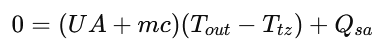

In [20]:
UA = 5
m = 6
c = 1
Ttz1 = 22
Ttz2 = 24
Qsa = 50

# denominador común
den = UA + m*c

# cálculo de temperaturas
t01 = Ttz1 - Qsa / den
t02 = Ttz2 - Qsa / den

print(f"t01 = {t01}")
print(f"t02 = {t02}")

t01 = 17.454545454545453
t02 = 19.454545454545453


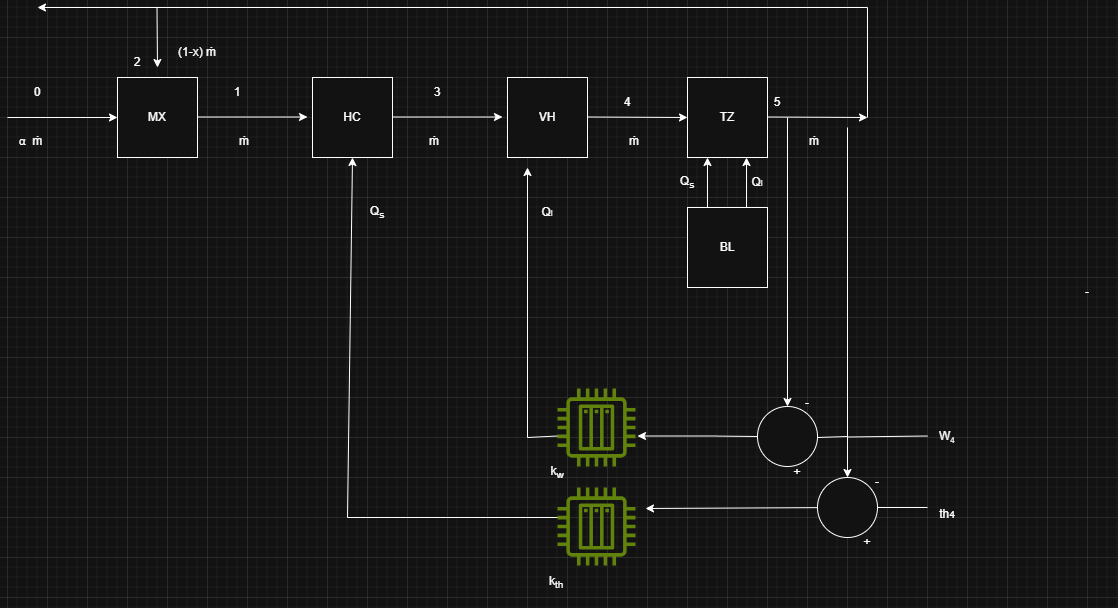

In [8]:
from IPython.display import Image, display

display(Image(filename='EVA_CE4AC_Process Schematic.png'))

In [4]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import matplotlib.pyplot as plt
import va_hum

# %matplotlib inline  # uncomment for inline figure
# uncomment for figure in separate window
# %matplotlib qt
# plt.show()

plt.rcParams["figure.figsize"] = (10, 7.7)
font = {'size': 16}
plt.rc('font', **font)

In [7]:
# Design conditions for CAV (to determine m)
θOd = -1        # °C, outdoor temperarture
θId = 18        # °C, indoor temperature
θSd = 30        # °C summply air temperature
mid = 0.0057    # kg/s, infiltration
Qsad = 216      # kW, sensible auxiliary load
Qlad = 145.2    # kW, latent auxliary load
mid = 0.0057    # kg/s, air infiltration mass flow rate
UAd = 85.9      # kJ/K, overall heat conductance

### Constant air volume (CAV)

- supply air mass flow rate: constant - determined for design conditions
- supply temperature varies

![winter_VaHum_Rec_CAV](./Figures/heat_VaHum_Rec_CAV.svg)
> Figure 3. CAV system for a single termal zone with AHU for heating and vapor humidification with recycled air.

The `RecAirCAV` function from module `va_hum.py` can be accessed directly.

Winter Recirculated_air CAV
m =  1.491 kg/s constant (from design conditions)
Design conditions θS =  30.0 °C,mi = 0.0 kg/s, θO = -1.0 °C, θI = 18.0 °C
wO = 0.00351


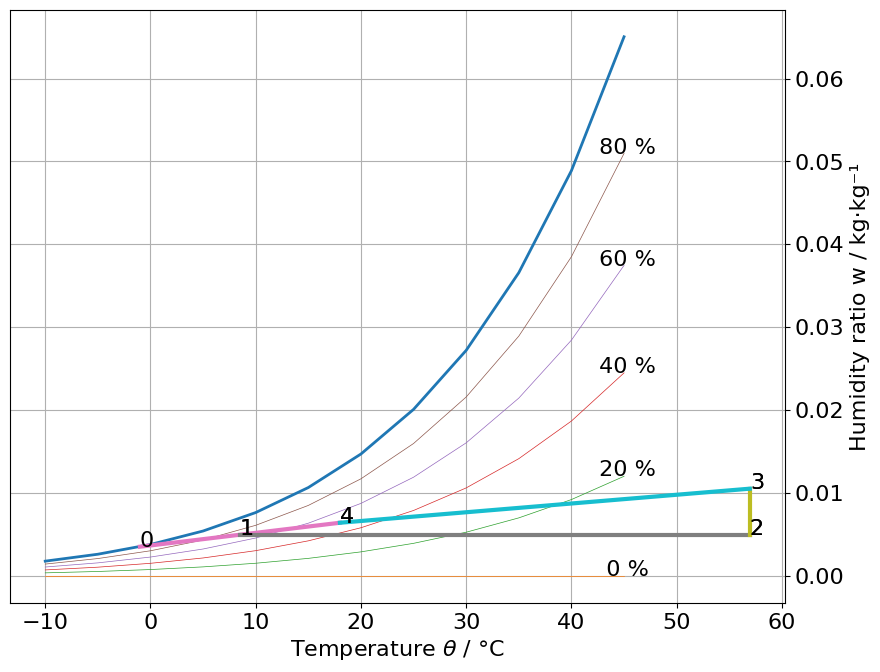


  θ [°C] w [g/kg]
0  -1.00     3.51
1   8.50     4.95
2  56.95     4.95
3  56.95    10.51
4  18.00     6.40

   QsHC  QlVH   QsTZ   QlTZ
0 72.22 20.68 -58.06 -15.30 kW


In [8]:
va_hum.RecAirCAV(α=0.5, θS=30, θIsp=18, φIsp=0.5, θO=-1, φO=1, Qsa=0, Qla=0, mi=2.12, UA=935.83)

#### Modify the operation

> Table 5. Widgets to modify the operation of the HVAC system.

|Widget| Symbol         |          | Unit| Meaning                               |
|------|----------------|----------|-----|---------------------------------------|
|`α`   |$\alpha$        |          |     |Proportion of outdoor air in the supply air|
|`θS`  |$\theta_S^{sp}$ |$\theta_2^{sp}$| °C|Set-point for supply air temperature   |
|`θIsp`|$\theta_I^{sp}$ |$\theta_3^{sp}$| °C|Set-point for indoor air temperature   |
|`φIsp`|$\varphi_I^{sp}$|$\varphi_3^{sp}$|  |Set-point for indoor relative humidity |
|`θO`  |$\theta_O$      |$\theta_0$| °C  |Outdoor air temperature                |
|`φO`  |$\varphi_O$     |$\varphi_0$|    |Outdoor air relative humidity          |


In [9]:
def RecAirCAV_wd(α=0.5, θS=30, θIsp=18, φIsp=0.5, θO=-1, φO=1):
    Qsa = 0.
    Qla = 0.
    mi = 1
    UA = 935.83
    from va_hum import RecAirCAV
    RecAirCAV(α, θS, θIsp, φIsp, θO, φO, Qsa, Qla, mi, UA)

In [10]:
interact(RecAirCAV_wd, α = (0, 1, 0.1), θS = (20, 50, 2),
         θIsp = (17, 25, 1), φIsp = (0, 1, 0.1),
         θO = (-10., 17., 2), φO = (0, 1, 0.1));

interactive(children=(FloatSlider(value=0.5, description='α', max=1.0), IntSlider(value=30, description='θS', …

#### Modify the characteristics of the building


> Table 6. Widgets to modify the characteritics of the building.

|Widget| Symbol         | Unit| Meaning                                   |
|------|----------------|-----|-------------------------------------------|
|`Qsa` |$\dot{Q}_{s,a}$ | W   |Auxiliary sensible heat of the thermal zone|
|`Qla` |$\dot{Q}_{l,a}$ | W   |Auxiliary latent heat of the thermal zone|
|`mi`  |$\dot{m}_i$     | kg/s|Mass flow rate of air infiltration into the thermal zone|
|`UA`  |$U A$           | W/°C|Overall thermal conductance of the thermal zone|

In [11]:
def RecAirCAV_wd(Qsa=0, Qla=0, mi=2.12, UA=935.83):
    α = 0.5
    θSsp = 30
    θIsp = 18
    φIsp = 0.5
    θO = -1
    φO = 1
    from va_hum import RecAirCAV
    RecAirCAV(α, θSsp, θIsp, φIsp, θO, φO, 
              Qsa, Qla, mi, UA);

In [12]:
interact(RecAirCAV_wd, Qsa=(0, 15000, 50), Qla=(0, 15000, 50),
         mi=(0, 5, 0.2), UA=(700, 1000, 10));

interactive(children=(IntSlider(value=0, description='Qsa', max=15000, step=50), IntSlider(value=0, descriptio…